# Bibliotecas Usadas

In [523]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# Função para plotar gŕaficos, baseado em duas colunas de um DataFrame

In [524]:
def plotar(dataframe, linha, coluna1, coluna2, titulo, xlabel, ylabel, funcao_comparacao=None, tlabel=None):
    plt.figure()
    plt.plot(dataframe.loc[:linha, coluna1], dataframe.loc[:linha, coluna2], label="Dados Experimentais")
    if funcao_comparacao:
        x = dataframe.loc[:linha, coluna1]
        y_comparacao = funcao_comparacao(x)
        plt.plot(x, y_comparacao, label=tlabel, linestyle="--")
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.show()

# Extração do dados de benchmark

In [525]:
df = pd.read_csv("resultados_benchmark.csv")
df

,idx,algoritmo,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,prim,10,9,0.200000,9,0,0,0.000000,0.000000,0.000000,18,18,0.000004,9,0.000017
1,2,kruskal,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,0,0,0.000000,9,0.000017
2,3,prim,10,9,0.200000,9,0,0,0.000000,0.000000,0.000000,18,18,0.000002,9,0.000012
3,4,kruskal,10,9,0.200000,8,34,9,0.000006,0.000006,0.000001,0,0,0.000000,9,0.000013
4,5,prim,10,14,0.311111,9,0,0,0.000000,0.000000,0.000000,28,28,0.000004,9,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,716,kruskal,200,17912,0.900101,504,2018,199,0.002290,0.002290,0.003076,0,0,0.000000,199,0.004626
716,717,prim,200,19900,1.000000,199,0,0,0.000000,0.000000,0.000000,39800,39800,0.004603,199,0.025270
717,718,kruskal,200,19900,1.000000,602,2410,199,0.002490,0.002490,0.003319,0,0,0.000000,199,0.005028
718,719,prim,200,19900,1.000000,199,0,0,0.000000,0.000000,0.000000,39800,39800,0.004157,199,0.025288


# Extração e análise dos dados do algoritmo Prim

## Extração dos dados do Prim e eliminação das colunas que não representam o algoritmo

In [526]:
df_prim = df[df["algoritmo"] == "prim"]
df_prim = df_prim.drop(columns=["algoritmo", "find_calls", "union_calls", "tempo_execucao_find", "tempo_execucao_union", "tempo_sort"])

## Modificação dos índices do DataFrame para melhorar a filtragem

In [527]:
df_prim.reset_index(drop=True, inplace=True)
df_prim.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,18,18,0.000004,9,0.000017
1,3,10,9,0.200000,9,18,18,0.000002,9,0.000012
2,5,10,14,0.311111,9,28,28,0.000004,9,0.000017
3,7,10,14,0.311111,9,28,28,0.000003,9,0.000016
4,9,10,22,0.488889,9,44,44,0.000005,9,0.000021
5,11,10,14,0.311111,9,28,28,0.000003,9,0.000015
6,13,10,20,0.444444,9,40,40,0.000004,9,0.000019
7,15,10,19,0.422222,9,38,38,0.000004,9,0.000019
8,17,10,27,0.600000,9,54,54,0.000006,9,0.000025
9,19,10,18,0.400000,9,36,36,0.000004,9,0.000020


In [528]:
np.array([0.0]) + np.arange(0.3, 1.1, 0.1)

array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

## Análise do algoritmo Prim com o aumento dos vertices

### Para melhor caso (grafo é uma AGM)

In [529]:
df_prim_vertice_melhor = df_prim.loc[df_prim["num_vertices"] == (df_prim["num_arestas"] + 1)]
df_prim_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_melhor.reset_index(drop=True, inplace=True)
df_prim_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,18,18,0.000004,9,0.000017
1,37,20,19,0.100000,19,38,38,0.000004,19,0.000019
2,73,30,29,0.066667,29,58,58,0.000005,29,0.000025
3,109,40,39,0.050000,39,78,78,0.000006,39,0.000031
4,145,50,49,0.040000,49,98,98,0.000008,49,0.000038
5,181,60,59,0.033333,59,118,118,0.000010,59,0.000047
6,217,70,69,0.028571,69,138,138,0.000011,69,0.000051
7,253,80,79,0.025000,79,158,158,0.000012,79,0.000059
8,289,90,89,0.022222,89,178,178,0.000013,89,0.000066
9,325,100,99,0.020000,99,198,198,0.000015,99,0.000072


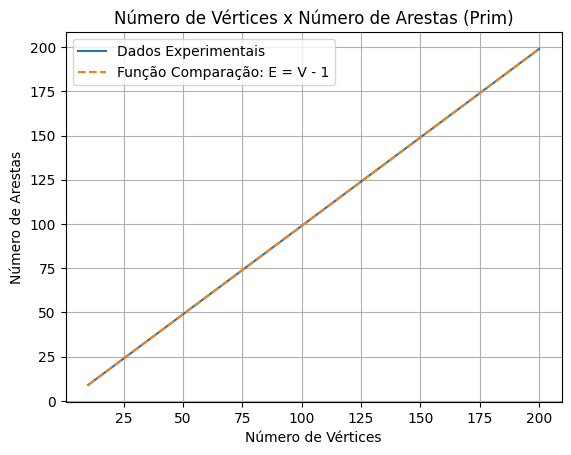

In [530]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

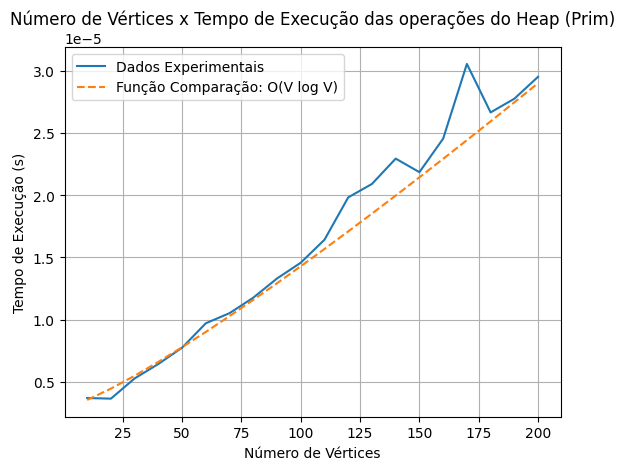

In [531]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 17e-9 * x * np.log2(x) + 0.000003,
    tlabel="Função Comparação: O(V log V)"
)

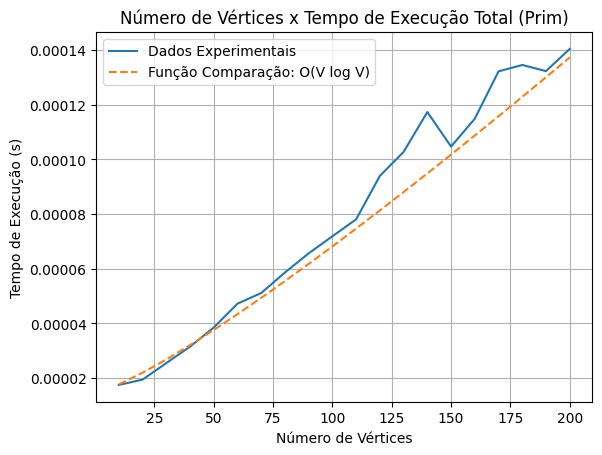

In [532]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 8e-8 * x * np.log2(x) + 0.000015,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
Para o melhor caso, o algortimo Prim possui complexidade $O(V \log V)$, possui nesse caso $E = V -1 $. Isso é refletido no tempo de execução do Heap,

### Para o pior caso, grafos densos

In [533]:
df_prim_vertice_pior = df_prim.sort_values(by="densidade", ascending=False)
df_prim_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_pior.reset_index(drop=True, inplace=True)
df_prim_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,33,10,45,1.0,9,90,90,0.000011,9,0.000042
1,71,20,190,1.0,19,380,380,0.000041,19,0.000160
2,107,30,435,1.0,29,870,870,0.000085,29,0.000362
3,143,40,780,1.0,39,1560,1560,0.000155,39,0.000689
4,177,50,1225,1.0,49,2450,2450,0.000276,49,0.001227
5,215,60,1770,1.0,59,3540,3540,0.000360,59,0.001706
6,249,70,2415,1.0,69,4830,4830,0.000502,69,0.002375
7,285,80,3160,1.0,79,6320,6320,0.000674,79,0.003172
8,321,90,4005,1.0,89,8010,8010,0.000855,89,0.004044
9,359,100,4950,1.0,99,9900,9900,0.001003,99,0.004950


Fixando a densidade em 1.0, as arestas serão encontradas por $E = V \cdot (V -1)$

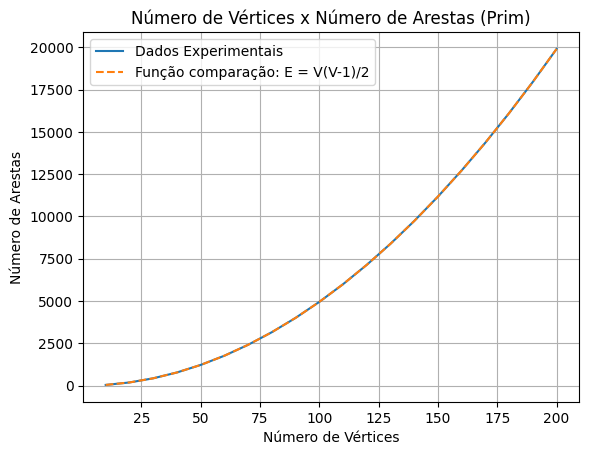

In [534]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Função comparação: E = V(V-1)/2"
)

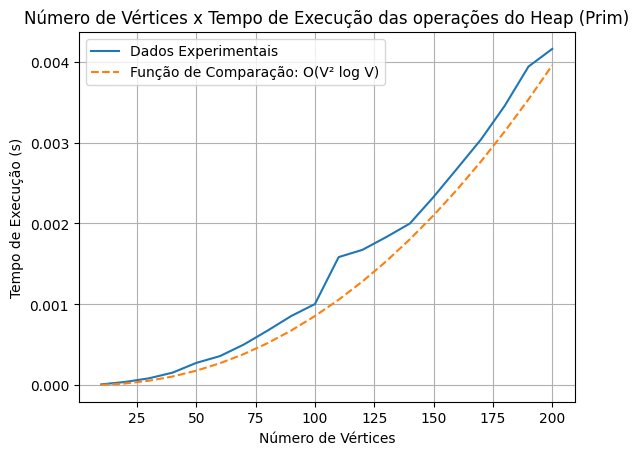

In [535]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 13e-9 * (x*(x-1)) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

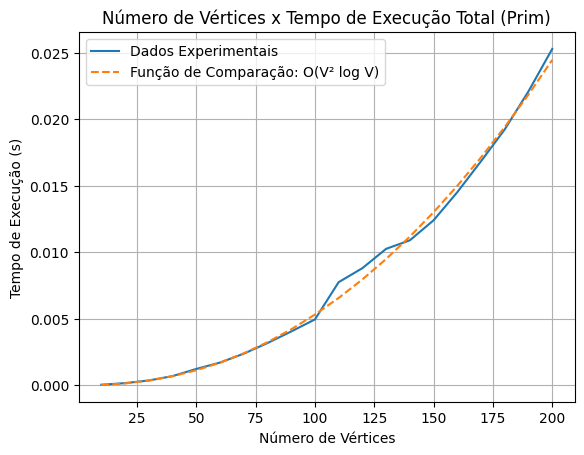

In [536]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 8e-8 * (x**2) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

### Conclusão
Ao se fixar a densidado, as arestas aumentam em $O(V²)$, assim a complexidade do Prim, dado por $O(E \log{V})$, transforma-se em $O(V^2 \log{V})$. Isso é refletido no tempo de execução total e no tempo de execução das operações do Heap, no pior caso.

## Análise do algorimto Prim com o aumento do número de arestas do grafo

In [537]:
df_prim_arestas = df_prim.sort_values(by="densidade")
maior_num_vertice = df_prim_arestas["num_vertices"].max()
df_prim_arestas = df_prim_arestas[df_prim_arestas["num_vertices"] == maior_num_vertice]
df_prim_arestas.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_prim_arestas.reset_index(drop=True, inplace=True)
df_prim_arestas

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,685,200,199,0.010000,199,398,398,0.000030,199,0.000140
1,691,200,5931,0.298040,199,11862,11862,0.001290,199,0.006325
2,689,200,5958,0.299397,199,11916,11916,0.001488,199,0.006535
3,695,200,7904,0.397186,199,15808,15808,0.001622,199,0.008453
4,693,200,8009,0.402462,199,16018,16018,0.001682,199,0.008637
5,697,200,9998,0.502412,199,19996,19996,0.002177,199,0.011234
6,699,200,10019,0.503467,199,20038,20038,0.002062,199,0.011007
7,701,200,11976,0.601809,199,23952,23952,0.002572,199,0.013757
8,703,200,12019,0.603970,199,24038,24038,0.002460,199,0.013599
9,707,200,13848,0.695879,199,27696,27696,0.002939,199,0.016128


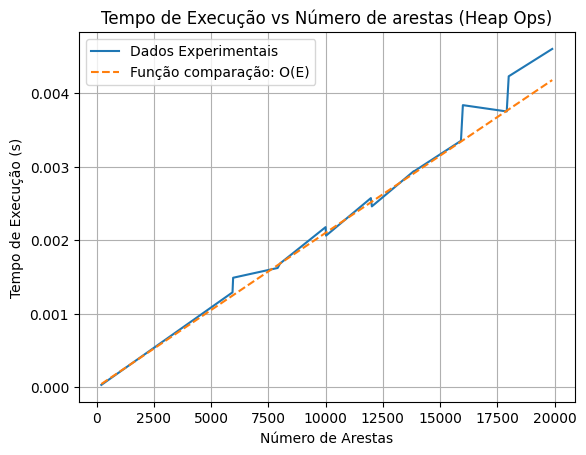

In [538]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Número de arestas (Heap Ops)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 21e-8 * x,
    tlabel="Função comparação: O(E)"
)

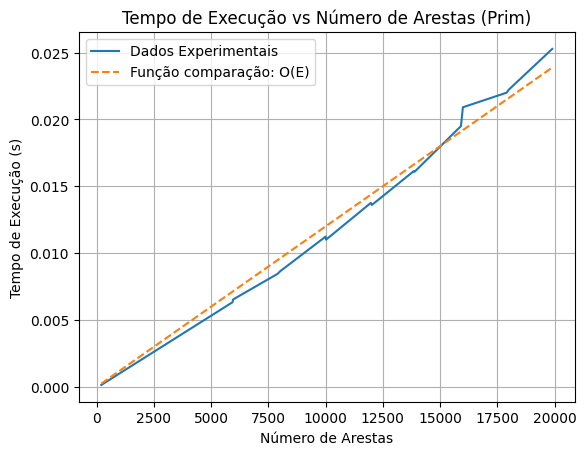

In [539]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução vs Número de Arestas (Prim)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 12e-7 * x,
    tlabel="Função comparação: O(E)"
)

### Conclusão
Ao fixar os vértices, a complexidade do Prim aumente pela função O(E), e visto que a densidade é proporcional ao número de arestas, pode-se dizer que o aumento da densidade resulta no aumento linear do tempo de execução

## Comparação do tempo gasto pelas operações do heap com o tempo gasto na totalidade

In [540]:
df_prim_copia = df_prim.copy()
df_prim_copia["porcentagem_heap_ops"] = (df_prim_copia["tempo_execucao_heap_ops"] / df_prim_copia["tempo_execucao_total"]) * 100
df_prim_copia

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total,porcentagem_heap_ops
0,1,10,9,0.200000,9,18,18,0.000004,9,0.000017,21.291947
1,3,10,9,0.200000,9,18,18,0.000002,9,0.000012,16.762696
2,5,10,14,0.311111,9,28,28,0.000004,9,0.000017,21.026866
3,7,10,14,0.311111,9,28,28,0.000003,9,0.000016,21.222648
4,9,10,22,0.488889,9,44,44,0.000005,9,0.000021,23.891175
...,...,...,...,...,...,...,...,...,...,...,...
355,711,200,15912,0.799598,199,31824,31824,0.003353,199,0.019499,17.193278
356,713,200,17999,0.904472,199,35998,35998,0.004231,199,0.022219,19.040269
357,715,200,17912,0.900101,199,35824,35824,0.003752,199,0.022000,17.054527
358,717,200,19900,1.000000,199,39800,39800,0.004603,199,0.025270,18.215849


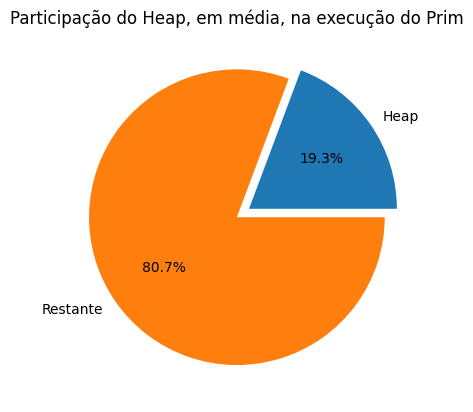

In [541]:
tempo_heap = df_prim["tempo_execucao_heap_ops"].mean()
tempo_total = df_prim["tempo_execucao_total"].mean()
tempo_resto = tempo_total - tempo_heap

plt.figure()
plt.pie(
    [tempo_heap, tempo_resto],
    labels=["Heap", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1, 0]
)
plt.title("Participação do Heap, em média, na execução do Prim")
plt.show()

### Conclusão
O tempo gasto nas operações do heap equivale, em média, a  menos de 20% do total do tempo de execução, evidenciando que as outras operações consomem mais tempo que a estrutura de prioridade.

## Conclusão Sobre o algoritmo de Prim
O algoritmo de Prim possui um melhor caso como $O(V \log V)$, um caso médio como $O(E \log V)$ e um pior caso como $O(V² \log V)$. Fortemente influênciado pela quantidade de vértices

# Extração e análise dos dados do algoritmo Kruskal

In [542]:
df_kruskal = df[df["algoritmo"] == "kruskal"]
df_kruskal.drop(columns=["algoritmo", "heap_push", "heap_pop", "tempo_execucao_heap_ops"], inplace=True)

## Modificação dos índices do DataFrame para melhorar a filtragem

In [543]:
df_kruskal.reset_index(drop=True, inplace=True)
df_kruskal.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,9,0.000017
1,4,10,9,0.200000,8,34,9,0.000006,0.000006,0.000001,9,0.000013
2,6,10,14,0.311111,11,46,9,0.000007,0.000007,0.000002,9,0.000015
3,8,10,14,0.311111,11,46,9,0.000006,0.000006,0.000002,9,0.000015
4,10,10,22,0.488889,10,42,9,0.000007,0.000007,0.000003,9,0.000015
5,12,10,14,0.311111,9,38,9,0.000006,0.000006,0.000002,9,0.000013
6,14,10,20,0.444444,16,66,9,0.000008,0.000008,0.000003,9,0.000017
7,16,10,19,0.422222,12,50,9,0.000008,0.000008,0.000003,9,0.000017
8,18,10,27,0.600000,11,46,9,0.000009,0.000009,0.000004,9,0.000019
9,20,10,18,0.400000,9,38,9,0.000007,0.000007,0.000003,9,0.000015


- Aumento de vértice x (find_calls, union_calls, tempo_execucao_total)
- Aumento da densidade x (find_calls, union_calls, tempo_execucao_total)
- pizza (tempo union, tempo sort, tempo total)

## Análise do Kruskal em relação ao aumento do número de vértices

### Melhor caso (grafo é uma árvore geradora mínima)

In [544]:
df_kruskal_vertice_melhor = df_kruskal.loc[df_kruskal["num_vertices"] == (df_kruskal["num_arestas"] + 1)]
df_kruskal_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_melhor.reset_index(drop=True, inplace=True)
df_kruskal_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,9,0.000017
1,38,20,19,0.100000,18,74,19,0.000009,0.000009,0.000002,19,0.000020
2,74,30,29,0.066667,28,114,29,0.000012,0.000012,0.000003,29,0.000027
3,110,40,39,0.050000,38,154,39,0.000015,0.000015,0.000003,39,0.000033
4,146,50,49,0.040000,48,194,49,0.000018,0.000018,0.000003,49,0.000039
5,182,60,59,0.033333,58,234,59,0.000024,0.000024,0.000004,59,0.000051
6,218,70,69,0.028571,68,274,69,0.000026,0.000026,0.000005,69,0.000055
7,254,80,79,0.025000,78,314,79,0.000030,0.000030,0.000005,79,0.000063
8,290,90,89,0.022222,88,354,89,0.000032,0.000032,0.000005,89,0.000069
9,326,100,99,0.020000,98,394,99,0.000036,0.000036,0.000006,99,0.000077


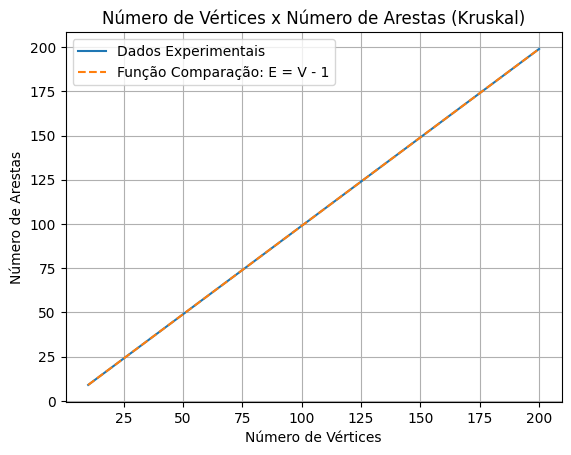

In [545]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

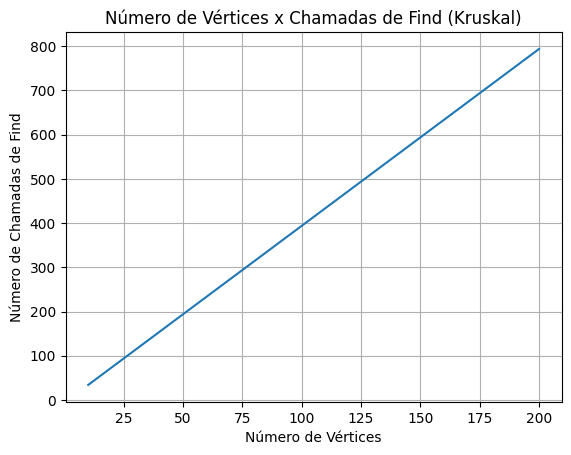

In [546]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find"
)

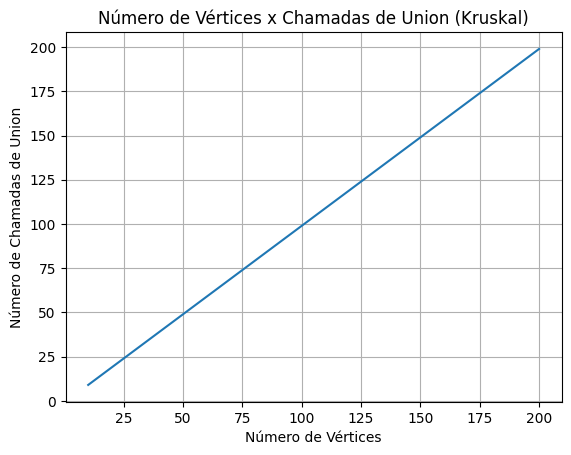

In [547]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union"
)

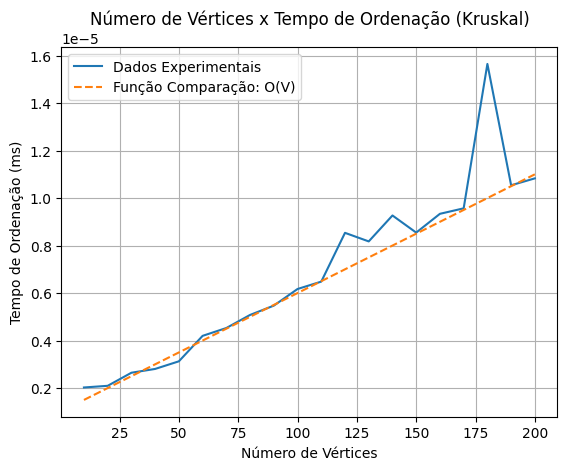

In [548]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao= lambda x : 5e-8 * x + 0.000001 ,
    tlabel="Função Comparação: O(V)"
)

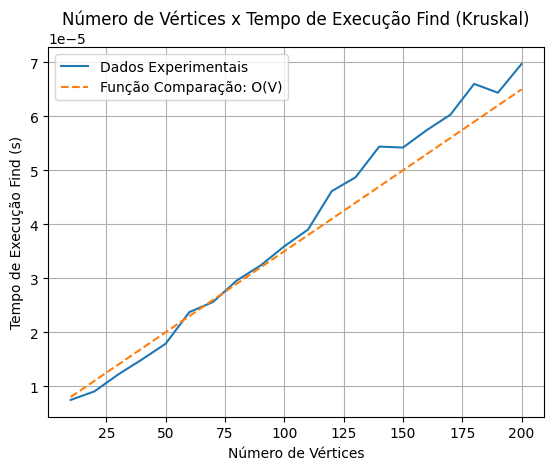

In [549]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_find",
    titulo="Número de Vértices x Tempo de Execução Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Find (s)",
    funcao_comparacao= lambda x : 3e-7 * x + 0.000005,
    tlabel="Função Comparação: O(V)"
)

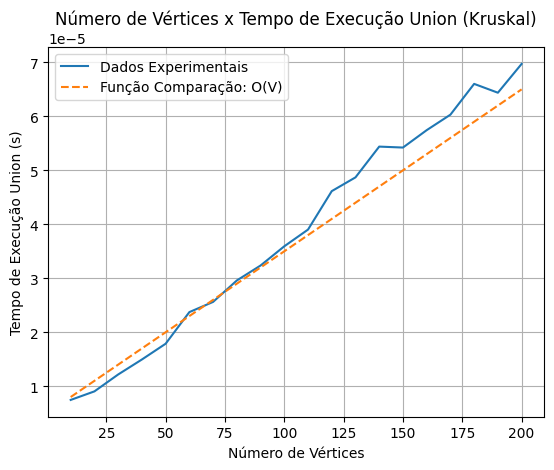

In [550]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_union",
    titulo="Número de Vértices x Tempo de Execução Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Union (s)",
    funcao_comparacao= lambda x : 3e-7 * x + 0.000005,
    tlabel="Função Comparação: O(V)"
)

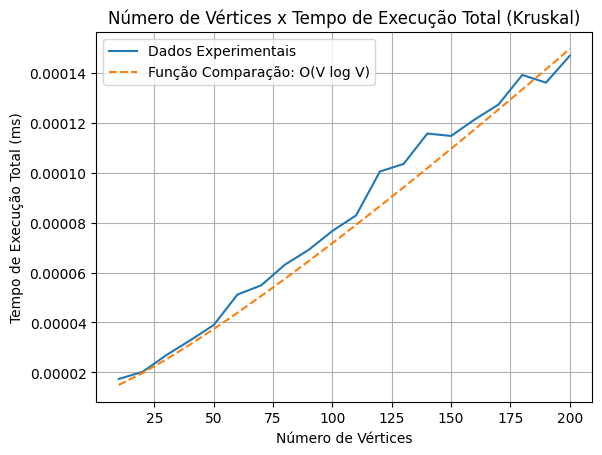

In [551]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (ms)",
    funcao_comparacao= lambda x : 9e-8 * x * np.log2(x) + 0.000012,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
A complexidade o algoritmo torna-se $O(V \log V)$ no melhor caso. O número de chamadas de Find cresce linearmente, pois o número de chamadas do union sempre será o número de arestas ad AGM, que é $V -1 $. Nesse caso, haverá uma razão entre o número de chamadas do Union e o número de chamadas do Find, tendendo ao 0.25. Segue tabelas de comparação:

Também é interessante notar que mesmo que o tempo de execução do find e do union são lineares, pois operações envonvendo conjunto são lineares assintoticamente, ou seja tornam-se O(E), que no melhor caso fica O(V). Outro fator importante é que a função de ordenação usada é o TimSort, nativo do python, que em seu melhor caso gera complexidade O(n), no nosso caso, O(V)

In [552]:
table = df_kruskal_vertice_melhor[["num_vertices", "num_arestas", "find_calls", "union_calls"]]
table["razão (Union/Find)"] = table["union_calls"] / table["find_calls"]
display(Markdown("### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso"))
display(table)

### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso

,num_vertices,num_arestas,find_calls,union_calls,razão (Union/Find)
0,10,9,34,9,0.264706
1,20,19,74,19,0.256757
2,30,29,114,29,0.254386
3,40,39,154,39,0.253247
4,50,49,194,49,0.252577
5,60,59,234,59,0.252137
6,70,69,274,69,0.251825
7,80,79,314,79,0.251592
8,90,89,354,89,0.251412
9,100,99,394,99,0.251269


### Pior caso (Árvore Densa)

In [553]:
df_kruskal_vertice_pior = df_kruskal.sort_values(by="densidade", ascending=False)
df_kruskal_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_pior.reset_index(drop=True, inplace=True)
df_kruskal_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,34,10,45,1.0,9,38,9,0.000011,0.000011,0.000009,9,0.000025
1,72,20,190,1.0,32,130,19,0.000030,0.000030,0.000028,19,0.000062
2,108,30,435,1.0,32,130,29,0.000056,0.000056,0.000066,29,0.000115
3,144,40,780,1.0,86,346,39,0.000104,0.000104,0.000117,39,0.000212
4,178,50,1225,1.0,116,466,49,0.000161,0.000161,0.000181,49,0.000328
5,216,60,1770,1.0,89,358,59,0.000216,0.000216,0.000263,59,0.000439
6,250,70,2415,1.0,146,586,69,0.000284,0.000284,0.000337,69,0.000575
7,286,80,3160,1.0,131,526,79,0.000348,0.000348,0.000435,79,0.000704
8,322,90,4005,1.0,164,658,89,0.000447,0.000447,0.000567,89,0.000904
9,360,100,4950,1.0,587,2350,99,0.000636,0.000636,0.000699,99,0.001285


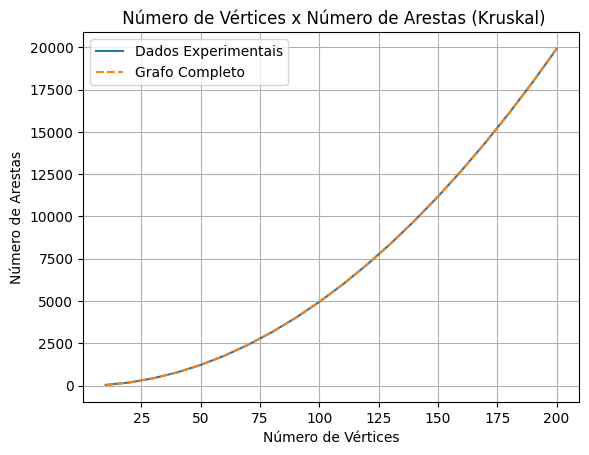

In [554]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo=" Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Grafo Completo"
)

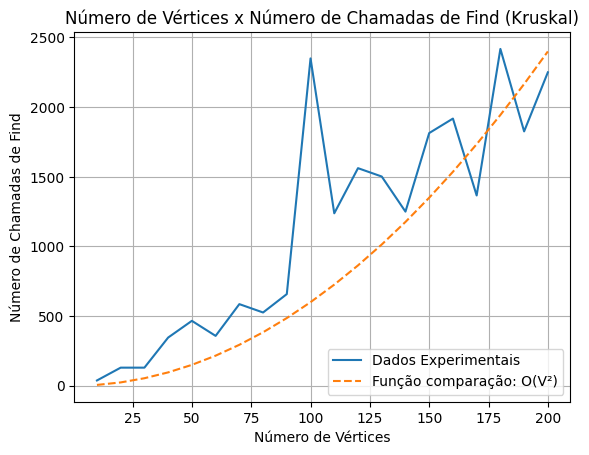

In [555]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Número de Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find",
    funcao_comparacao=lambda x : 6e-2 * x**2, #No pior caso o número de chamadas é O(V²)
    tlabel="Função comparação: O(V²)"
)

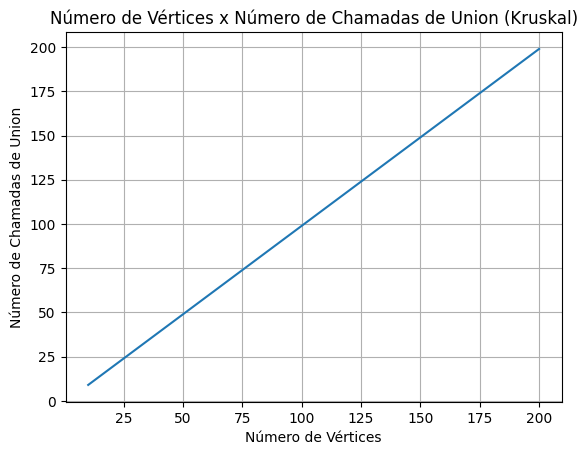

In [556]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Número de Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union"
)

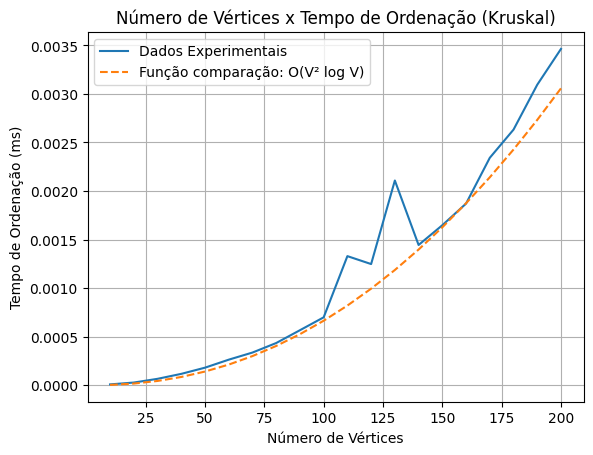

In [557]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao=lambda x : 1e-8 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

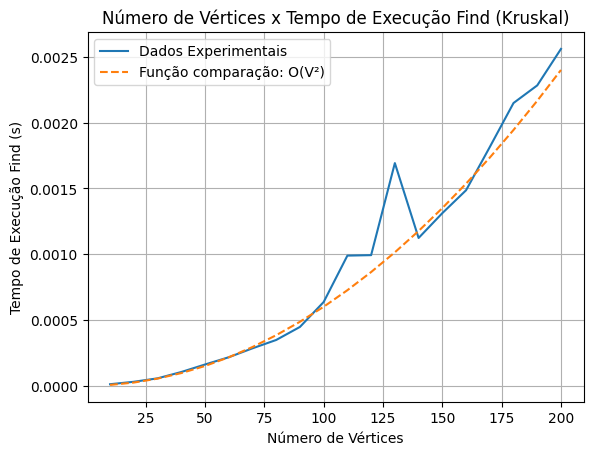

In [558]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_find",
    titulo="Número de Vértices x Tempo de Execução Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Find (s)",
    funcao_comparacao=lambda x: 6e-8 * x**2,
    tlabel="Função comparação: O(V²)"
)

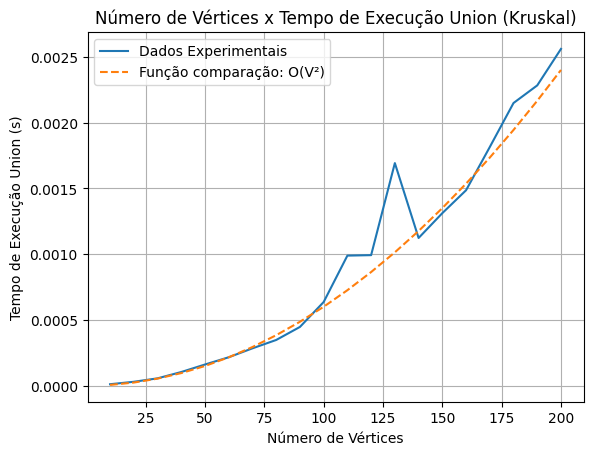

In [559]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_union",
    titulo="Número de Vértices x Tempo de Execução Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Union (s)",
    funcao_comparacao=lambda x: 6e-8 * x**2,
    tlabel="Função comparação: O(V²)"
)

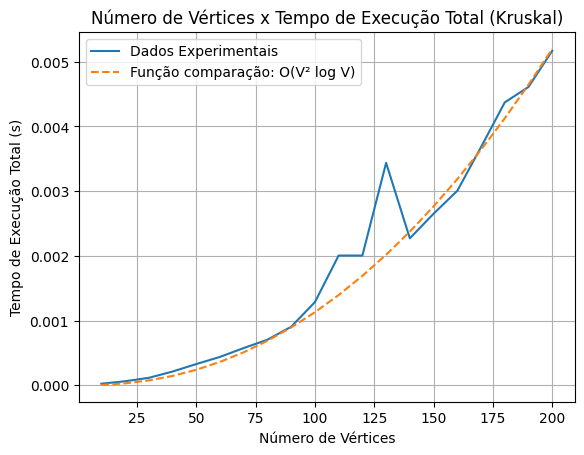

In [560]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x: 17e-9 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

### Conclusão
O tempo de ordenação é $O(E \log E)$, que no pior caso se torna, $O(V² \log V)$. Os tempos de execução do find e do union são lineares em relação à |E|, assim tornam-se quadráticos em relação à V. A complexidade do Kruskal é $O(V² \log V)$ no pior caso.

## Análise do algorimto Kruskal com o aumento do número de arestas do grafo

In [561]:
df_kruskal_densidade = df_kruskal.sort_values(by="densidade")
maior_num_vertice = df_kruskal_densidade["num_vertices"].max()
df_kruskal_densidade = df_kruskal_densidade[df_kruskal_densidade["num_vertices"] == maior_num_vertice]
df_kruskal_densidade.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_kruskal_densidade.reset_index(drop=True, inplace=True)
df_kruskal_densidade

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,686,200,199,0.010000,198,794,199,0.000070,0.000070,0.000011,199,0.000147
1,692,200,5931,0.298040,558,2234,199,0.000760,0.000760,0.000842,199,0.001539
2,690,200,5958,0.299397,535,2142,199,0.000759,0.000759,0.000847,199,0.001537
3,696,200,7904,0.397186,528,2114,199,0.000958,0.000958,0.001120,199,0.001940
4,694,200,8009,0.402462,497,1990,199,0.000965,0.000965,0.001156,199,0.001953
5,698,200,9998,0.502412,649,2598,199,0.001216,0.001216,0.001454,199,0.002461
6,700,200,10019,0.503467,470,1882,199,0.001167,0.001167,0.001427,199,0.002360
7,702,200,11976,0.601809,419,1678,199,0.001385,0.001385,0.001761,199,0.002800
8,704,200,12019,0.603970,732,2930,199,0.001466,0.001466,0.001778,199,0.002965
9,708,200,13848,0.695879,426,1706,199,0.001644,0.001644,0.002132,199,0.003324


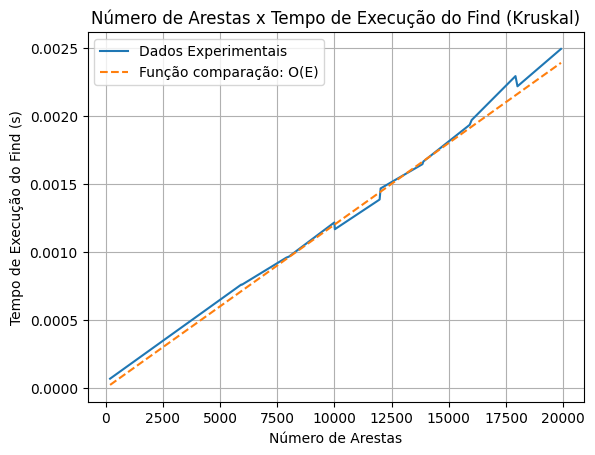

In [562]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_find",
    titulo="Número de Arestas x Tempo de Execução do Find (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução do Find (s)",
    funcao_comparacao=lambda x : 12e-8 * x,
    tlabel="Função comparação: O(E)"
)

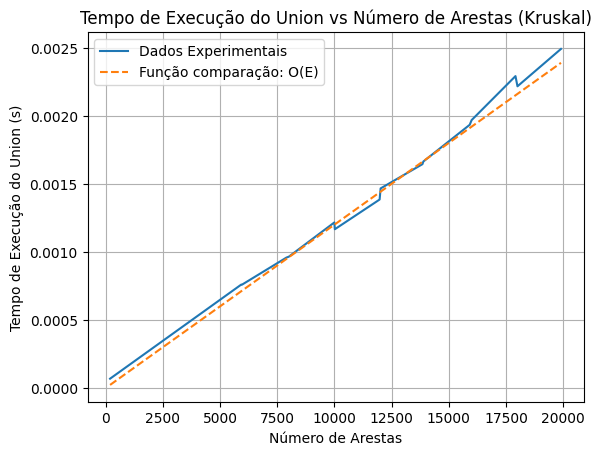

In [563]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_union",
    titulo="Tempo de Execução do Union vs Número de Arestas (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução do Union (s)",
    funcao_comparacao=lambda x : 12e-8 * x,
tlabel="Função comparação: O(E)"
)

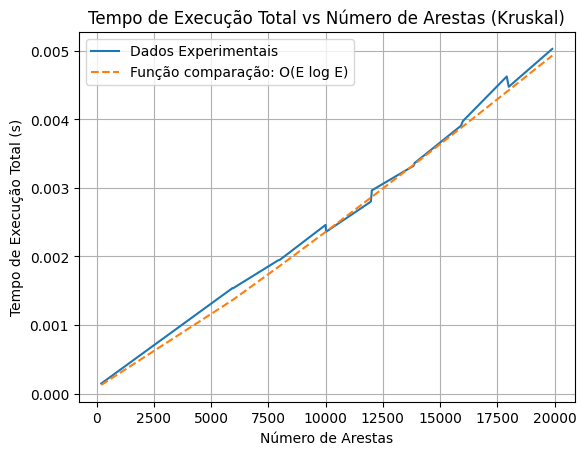

In [564]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução Total vs Número de Arestas (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x : 17e-9 * x * np.log2(x) + 0.0001,
    tlabel="Função comparação: O(E log E)"
)

### Conclusão
Para o mesmo número de vértices, o aumento da densidade (número de arestas) corresponde a um aumento linear dos tempos de execução das operações de conjunto enquanto a ordenação cresce em ordem superlinear (E log E)

## Comparação entre o tempo gasto pelas operações de conjunto, pelo ordenação e o total

In [565]:
df_kruskal_comparacao = df_kruskal[["num_vertices", "num_arestas", "tempo_sort", "tempo_execucao_total"]]
df_kruskal_comparacao.head(10)

,num_vertices,num_arestas,tempo_sort,tempo_execucao_total
0,10,9,0.000002,0.000017
1,10,9,0.000001,0.000013
2,10,14,0.000002,0.000015
3,10,14,0.000002,0.000015
4,10,22,0.000003,0.000015
5,10,14,0.000002,0.000013
6,10,20,0.000003,0.000017
7,10,19,0.000003,0.000017
8,10,27,0.000004,0.000019
9,10,18,0.000003,0.000015


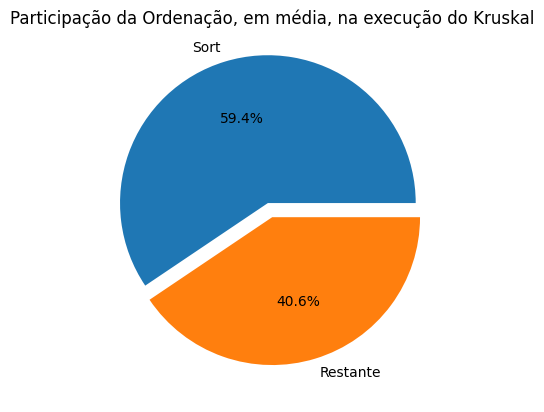

In [566]:
tempo_total = df_kruskal_comparacao["tempo_execucao_total"].mean()
tempo_sort = df_kruskal_comparacao["tempo_sort"].mean()
tempo_resto = tempo_total - tempo_sort

plt.figure()
plt.pie(
    [tempo_sort, tempo_resto],
    labels=["Sort", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1,  0]
)
plt.title("Participação da Ordenação, em média, na execução do Kruskal")
plt.show()

## Conclusão
O gráfico mostra que a ordenação compões significativamente o tempo de execução do Kruskal

# Comparações entre algortimos
retire os resultados diretamente aqui

In [567]:
def plotar_comparacao(dataframe1, dataframe2, linha, coluna1, coluna2, titulo, xlabel, ylabel):
    plt.figure()
    plt.plot(dataframe1.loc[:linha, coluna1], dataframe1.loc[:linha, coluna2], label="Prim")
    plt.plot(dataframe2.loc[:linha, coluna1], dataframe2.loc[:linha, coluna2], label="Kruskal")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

# Melhor caso para densidade constante

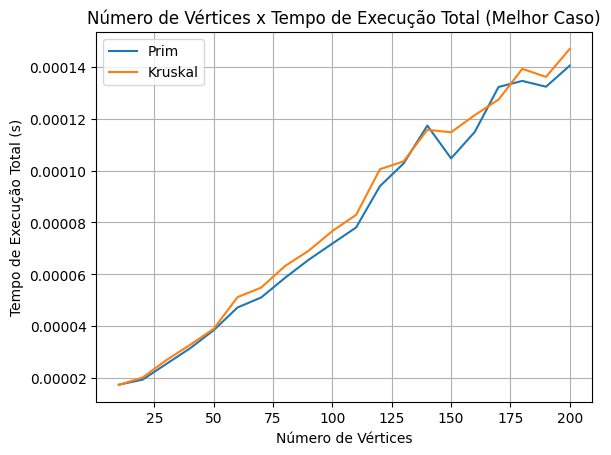

In [568]:
plotar_comparacao(
    df_prim_vertice_melhor,
    df_kruskal_vertice_melhor,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Melhor Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Pior caso para densidade constante

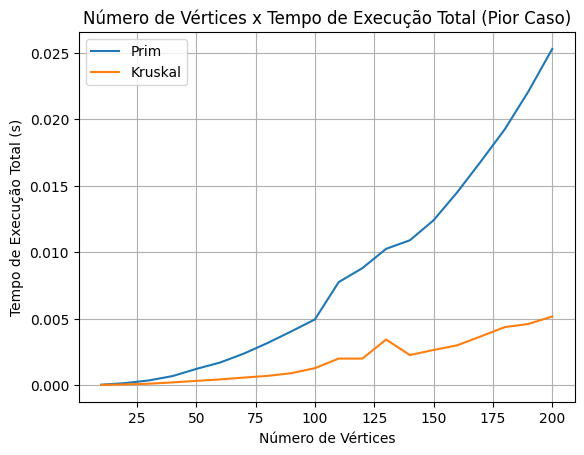

In [569]:
plotar_comparacao(
    df_prim_vertice_pior,
    df_kruskal_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Pior Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Vértices constantes

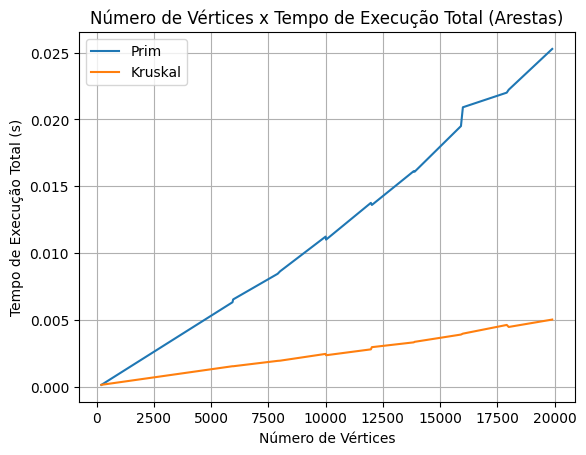

In [572]:
plotar_comparacao(
    df_prim_arestas,
    df_kruskal_densidade,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Arestas)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Observação
A implementação do Prim não está otimizada:
- O código duplica arestas desnecessariamente
- A condição de parada do Prim não é a formação da AGM, mas sim se o heap estiver vazio

Desse modo, o kruskal parace ser melhor no pior caso sendo que é o contrário, por isso precisa ajeitar essa parte do código o quanto antes